Імпорт бібліотек

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

c:\Users\regtf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Завантаження датасету

In [9]:
# Завантаження датасету
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
file_path = path + "\IMDB Dataset.csv"

print("Path to dataset files:", file_path)

<>:3: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:3: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\regtf\AppData\Local\Temp\ipykernel_17804\3487497837.py:3: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  file_path = path + "\IMDB Dataset.csv"


Path to dataset files: C:\Users\regtf\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1\IMDB Dataset.csv


Інформація про датасет

In [10]:
df = pd.read_csv(file_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [11]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Класи середовища, сенсору, агентів та критика (оцінок)

In [12]:
class IMDBEnvironment:
    """Клас середовища, яке зберігає дані та видає їх агентам"""
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        if self.df['sentiment'].dtype == 'object':   # Перетворення текстових міток у бінарний формат (1 - позитивний, 0 - негативний)
            self.df['sentiment'] = self.df['sentiment'].map({'positive': 1, 'negative': 0})
            
    def get_data_splits(self, test_size=0.2):   # Розділ датасету на тренувальний та тестовий
        print("Розділення даних на тренувальну та тестову вибірки...")
        return train_test_split(
            self.df['review'], self.df['sentiment'], 
            test_size=test_size, random_state=42
        )

class TFIDFSensor:
    """Cенсор для перетворення тексту у векторний стан за допомогою TF-IDF"""
    def __init__(self, max_features=5000):    # Чому гіперпараметр max_features=5000 детальніше в звіті
        self.vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')   # stop_words='english', щоб уникнути шуму від найбільш вживаних технічних слів, які існують лише для граматики, детальніше в звіті
        
    def perceive_train(self, raw_texts):
        print(f"Сенсор векторизує тренувальні дані (max_features={self.vectorizer.max_features})...")
        return self.vectorizer.fit_transform(raw_texts)   # Векторизація з навчанням
        
    def perceive_test(self, raw_texts):
        print("Сенсор векторизує тестові дані...")
        return self.vectorizer.transform(raw_texts)   # Векторизація без навчання

class TextClassifierAgent:
    """Батьківський клас агента"""
    def __init__(self, name):
        self.name = name
        self.model = None

    def learn(self, states, labels):
        self.model.fit(states, labels)

    def act(self, states):
        return self.model.predict(states)

class NaiveBayesAgent(TextClassifierAgent):
    """Дочірній клас агента"""
    def __init__(self):
        super().__init__("Naive Bayes")
        self.model = MultinomialNB()

class LogisticRegressionAgent(TextClassifierAgent):
    """Дочірній клас агента"""
    def __init__(self):
        super().__init__("Logistic Regression")
        self.model = LogisticRegression(max_iter=1000)   # max_iter=1000 щоб алгоритму вистачало кроків, 100 буде замало через векторизацію

class SVMAgent(TextClassifierAgent):
    """Дочірній клас агента"""
    def __init__(self):
        super().__init__("Linear SVM")
        self.model = LinearSVC(dual=False)   # dual=False рекомендовано для текстових даних

class Critic:
    """Критик, що оцінює дії агентів за допомогою метрик, вибір метрик обгрунтовано в звіті"""
    @staticmethod
    def evaluate(true_labels, predictions):
        acc = accuracy_score(true_labels, predictions)
        f1 = f1_score(true_labels, predictions, pos_label='positive')  # Явно вказано, що позитивний клас називається 'positive'
        cm = confusion_matrix(true_labels, predictions, labels=['negative', 'positive'])   # Фіксація порядку класів, щоб матриця помилок малювалася правильно
        return acc, f1, cm

Клас симулятора, через який буде відбуватися запуск та візуалізація результатів

In [13]:
class SimulationRunner:
    """Координатор для запуску експериментів та збору статистику"""
    def __init__(self, environment, sensor, agents):
        self.env = environment   # Інніціалізація
        self.sensor = sensor
        self.agents = agents
        self.results = []
        self.confusion_matrices = {}

    def run(self):
        review_train_raw, review_test_raw, sentiment_train, sentiment_test = self.env.get_data_splits()  # Отримання данних з середовища
        
        review_train = self.sensor.perceive_train(review_train_raw)   # Сенсор перетворює тексти у стани
        review_test = self.sensor.perceive_test(review_test_raw)
        
        print("\nПочаток симуляції...")
        for agent in self.agents:   # Цикл навчання та оцінки для кожного агента
            print(f"-> Агент [{agent.name}] починає навчання...")
            
            start_train = time.time()   # Вимірювання часу навчання
            agent.learn(review_train, sentiment_train)
            train_time = time.time() - start_train
            
            start_pred = time.time()   # Вимірювання часу прийняття рішень
            predictions = agent.act(review_test)
            pred_time = time.time() - start_pred
            
            acc, f1, cm = Critic.evaluate(sentiment_test, predictions)   # Оцінка результатів
            
            self.results.append({   # Збереження результатів
                "Агент": agent.name,
                "Accuracy": acc,
                "F1-Score": f1,
                "Час навчання (с)": train_time,
                "Час передбачення (с)": pred_time
            })
            self.confusion_matrices[agent.name] = cm
            
            print(f"   Готово! Точність: {acc:.4f}, Час: {train_time:.2f}с")
            
        return pd.DataFrame(self.results)

    def plot_results(self, df_results):
        """Візуалізація результатів"""
        sns.set_theme(style="whitegrid")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        
        # Порівняння метрик (Accuracy та F1)
        df_melted = df_results.melt(id_vars="Агент", value_vars=["Accuracy", "F1-Score"], 
                                    var_name="Метрика", value_name="Значення")
        sns.barplot(data=df_melted, x="Агент", y="Значення", hue="Метрика", ax=ax[0], palette="viridis")
        ax[0].set_title("Порівняння якості моделей (Accuracy та F1-Score)")
        ax[0].set_ylim(0.8, 1.0) # Зазвичай на IMDB точність > 0.8

        
        # Порівнння часових витрат та якості
        sns.scatterplot(data=df_results, x="Час навчання (с)", y="F1-Score", 
                        hue="Агент", s=200, ax=ax[1], palette="Set1")
        ax[1].set_title("Ефективність: Час навчання vs Якість (F1)")
        
        plt.tight_layout()
        plt.show()

    def plot_confusion_matrices(self):
        """Матриця помилок для кожного агента"""
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Матриці помилок (Confusion Matrices)', fontsize=16)
        
        for ax, (name, cm) in zip(axes, self.confusion_matrices.items()):
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                        xticklabels=['Negative', 'Positive'], 
                        yticklabels=['Negative', 'Positive'])
            ax.set_title(f'Агент: {name}')
            ax.set_xlabel('Передбачений клас')
            ax.set_ylabel('Справжній клас')
            
        plt.tight_layout()
        plt.show()

Запуск та виведення таблиці результатів

In [ ]:
env = IMDBEnvironment(df)
sensor = TFIDFSensor(max_features=5000)
agents = [NaiveBayesAgent(), LogisticRegressionAgent(), SVMAgent()]

simulator = SimulationRunner(env, sensor, agents)
results_df = simulator.run()

print("\nТАБЛИЦЯ РЕЗУЛЬТАТІВ")
display(results_df)

Розділення даних на тренувальну та тестову вибірки...
Сенсор векторизує тренувальні дані (max_features=5000)...
Сенсор векторизує тестові дані...

Початок симуляції...
-> Агент [Naive Bayes] починає навчання...
   Готово! Точність: 0.8508, Час: 0.08с
-> Агент [Logistic Regression] починає навчання...
   Готово! Точність: 0.8889, Час: 0.34с
-> Агент [Linear SVM] починає навчання...
   Готово! Точність: 0.8772, Час: 0.72с

ТАБЛИЦЯ РЕЗУЛЬТАТІВ


,Агент,Accuracy,F1-Score,Час навчання (с),Час передбачення (с)
0,Naive Bayes,0.8508,0.852131,0.081566,0.003102
1,Logistic Regression,0.8889,0.891408,0.338505,0.002108
2,Linear SVM,0.8772,0.879348,0.717281,0.002055


Графіки порівння якості моделей та часу роботи

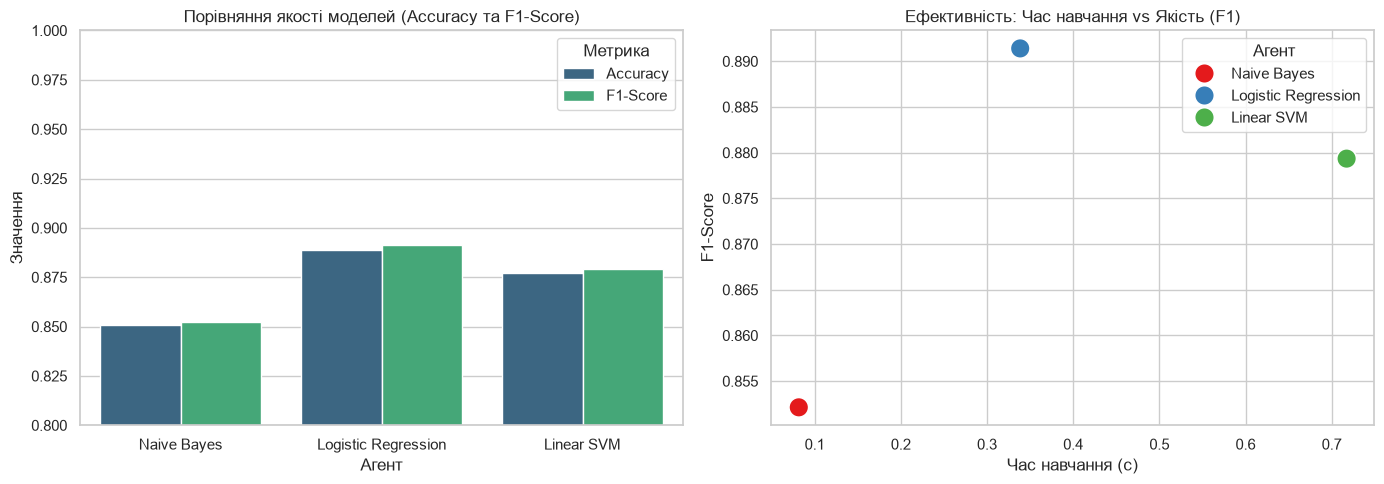

In [15]:
simulator.plot_results(results_df)

Матриця помилок з тепловою мапою

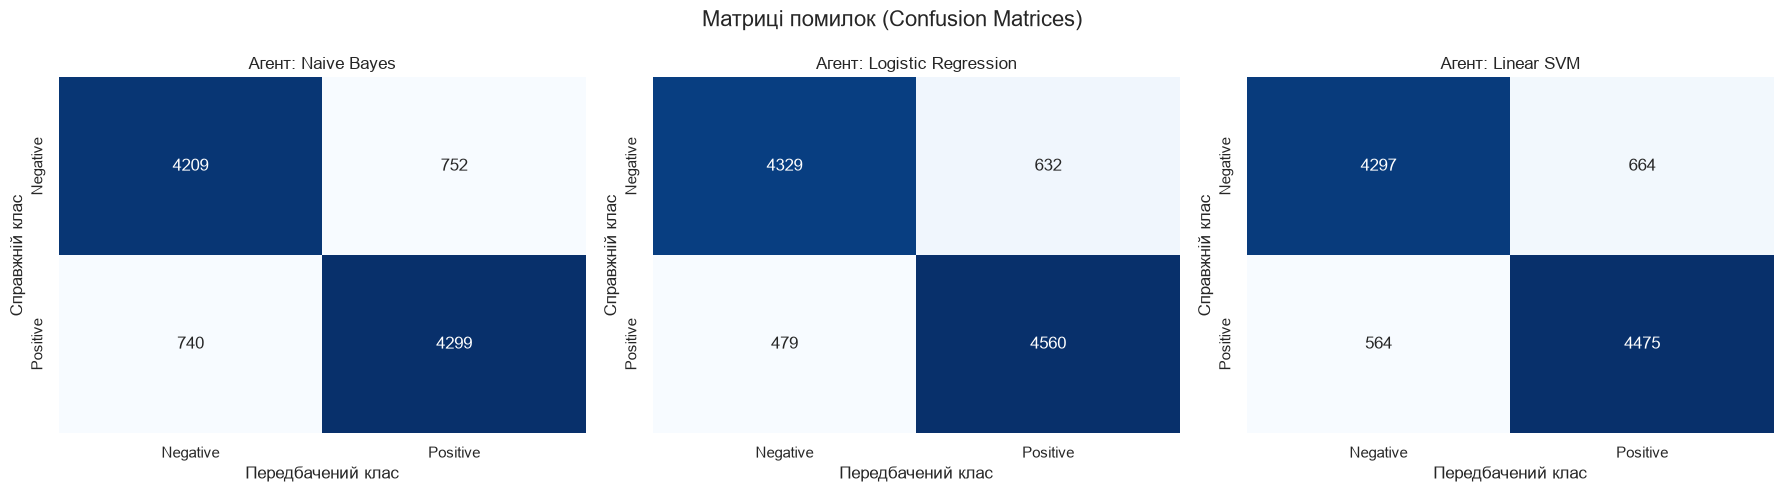

In [16]:
simulator.plot_confusion_matrices()

In [17]:
max_features_list = [500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 25000]
experiment_results = []

print("Отримання сирих даних із середовища...")
X_train_raw, X_test_raw, y_train, y_test = env.get_data_splits()

for mf in max_features_list:
    print(f"\n=== Експеримент з max_features = {mf} ===")
    
    sensor = TFIDFSensor(max_features=mf)
    X_train = sensor.perceive_train(X_train_raw)
    X_test = sensor.perceive_test(X_test_raw)
    
    agents = [NaiveBayesAgent(), LogisticRegressionAgent(), SVMAgent()]
    
    for agent in agents:
        start_train = time.time()
        agent.learn(X_train, y_train)
        train_time = time.time() - start_train
        
        start_pred = time.time()
        preds = agent.act(X_test)
        pred_time = time.time() - start_pred
        
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, pos_label='positive')
        total_time = train_time + pred_time
        
        experiment_results.append({
            "Max Features": mf,
            "Агент": agent.name,
            "Accuracy": acc,
            "F1-Score": f1,
            "Загальний час (с)": total_time
        })
        print(f"  [{agent.name}] завершив. F1: {f1:.4f}, Час: {total_time:.2f}с")

df_hyperparam = pd.DataFrame(experiment_results)


print("\n--- ДЕТАЛЬНІ РЕЗУЛЬТАТИ ---")
display(df_hyperparam.pivot(index='Max Features', columns='Агент', values=['F1-Score', 'Загальний час (с)']))

Отримання сирих даних із середовища...
Розділення даних на тренувальну та тестову вибірки...

=== Експеримент з max_features = 500 ===
Сенсор векторизує тренувальні дані (max_features=500)...
Сенсор векторизує тестові дані...
  [Naive Bayes] завершив. F1: 0.8215, Час: 0.05с
  [Logistic Regression] завершив. F1: 0.8447, Час: 0.15с
  [Linear SVM] завершив. F1: 0.8439, Час: 0.37с

=== Експеримент з max_features = 1000 ===
Сенсор векторизує тренувальні дані (max_features=1000)...
Сенсор векторизує тестові дані...
  [Naive Bayes] завершив. F1: 0.8365, Час: 0.04с
  [Logistic Regression] завершив. F1: 0.8699, Час: 0.16с
  [Linear SVM] завершив. F1: 0.8678, Час: 0.44с

=== Експеримент з max_features = 2000 ===
Сенсор векторизує тренувальні дані (max_features=2000)...
Сенсор векторизує тестові дані...
  [Naive Bayes] завершив. F1: 0.8470, Час: 0.05с
  [Logistic Regression] завершив. F1: 0.8810, Час: 0.16с
  [Linear SVM] завершив. F1: 0.8759, Час: 0.48с

=== Експеримент з max_features = 3000 ===

F1-Score                                 Загальний час (с)  \
Агент        Linear SVM Logistic Regression Naive Bayes        Linear SVM   
Max Features                                                                
500            0.843857            0.844675    0.821530          0.366097   
1000           0.867769            0.869913    0.836541          0.439561   
2000           0.875898            0.880964    0.847001          0.482202   
3000           0.881156            0.888280    0.851998          0.657417   
4000           0.878378            0.890125    0.852333          0.624241   
5000           0.879348            0.891408    0.852131          0.616627   
6000           0.880441            0.891258    0.852215          0.647711   
7000           0.880173            0.891971    0.855137          0.653839   
8000           0.881426            0.893014    0.856520          0.758220   
9000           0.882475            0.893467    0.856463          0.800413   
10000          0.882776            0.893659    0.858733          0.717311   
25000          0.892417            0.897205    0.862034          0.826737   

                                              
Агент        Logistic Regression Naive Bayes  
Max Features                                  
500                     0.148999    0.050538  
1000                    0.164759    0.044240  
2000                    0.162387    0.048816  
3000                    0.237378    0.054430  
4000                    0.259485    0.048575  
5000                    0.302394    0.048577  
6000                    0.234397    0.049408  
7000                    0.222056    0.050449  
8000                    0.347870    0.048760  
9000                    0.331077    0.050851  
10000                   0.447941    0.049797  
25000                   0.609536    0.051787

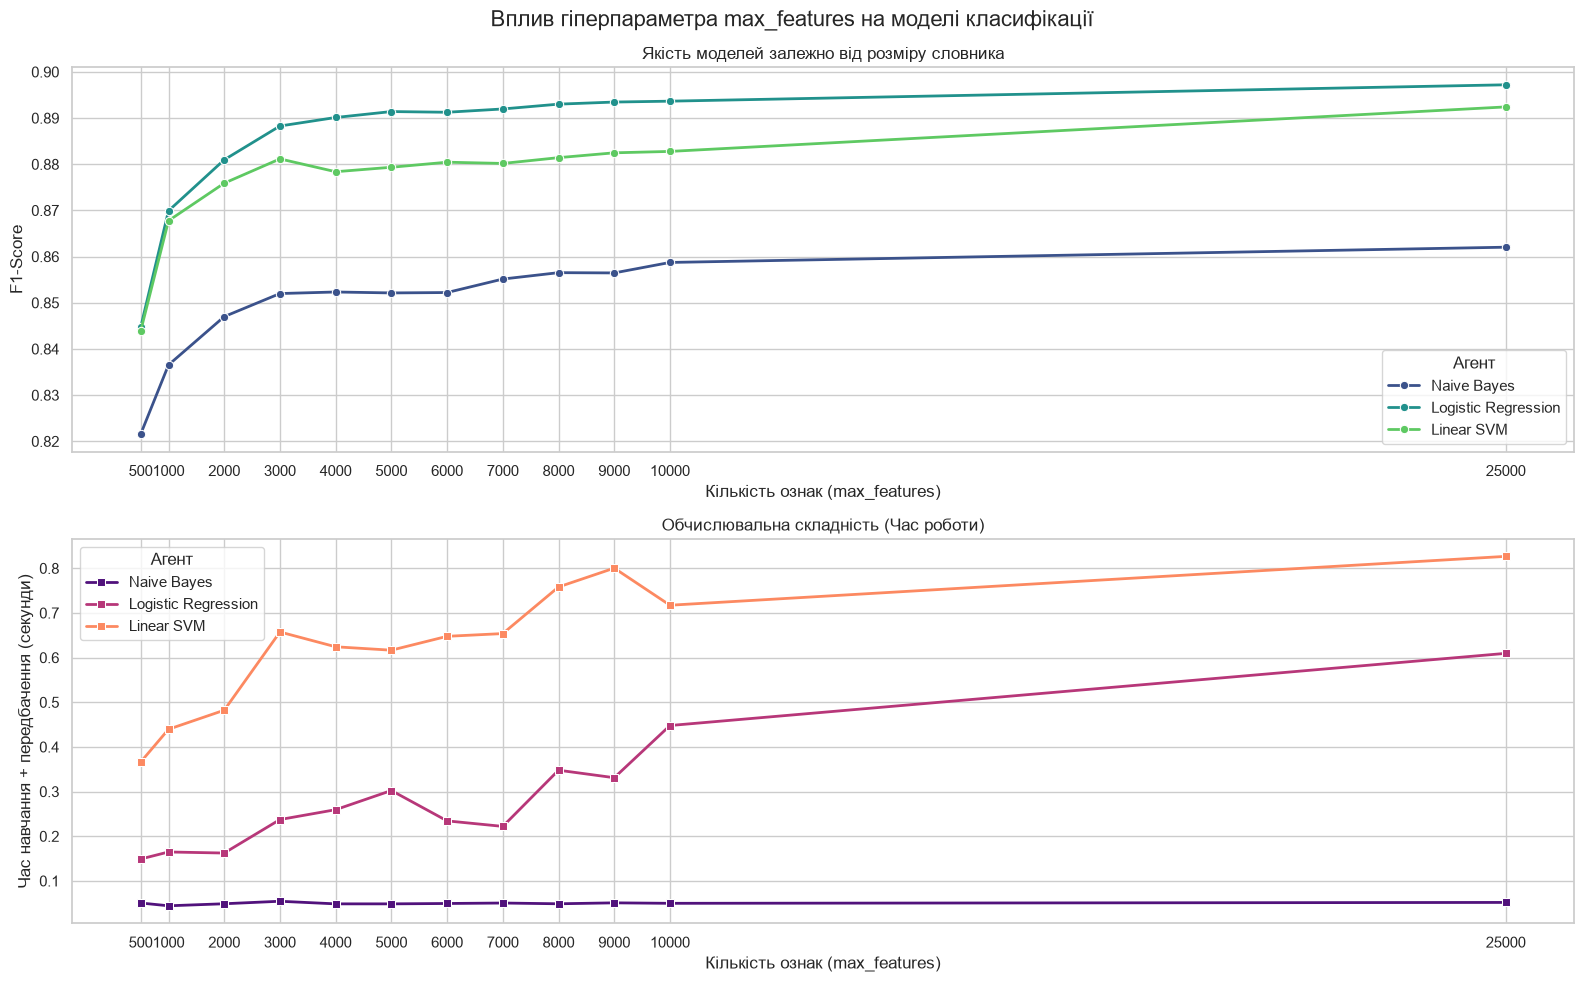

In [18]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Вплив гіперпараметра max_features на моделі класифікації', fontsize=16)

# F1-Score
sns.lineplot(data=df_hyperparam, x="Max Features", y="F1-Score", hue="Агент", 
             marker="o", linewidth=2, ax=ax[0], palette="viridis")
ax[0].set_title("Якість моделей залежно від розміру словника")
ax[0].set_xlabel("Кількість ознак (max_features)")
ax[0].set_ylabel("F1-Score")
ax[0].set_xticks(max_features_list)

# Зростання часу
sns.lineplot(data=df_hyperparam, x="Max Features", y="Загальний час (с)", hue="Агент", 
             marker="s", linewidth=2, ax=ax[1], palette="magma")
ax[1].set_title("Обчислювальна складність (Час роботи)")
ax[1].set_xlabel("Кількість ознак (max_features)")
ax[1].set_ylabel("Час навчання + передбачення (секунди)")
ax[1].set_xticks(max_features_list)

plt.tight_layout()
plt.show()